In [1]:
import Pkg; Pkg.activate(@__DIR__); Pkg.instantiate()

  Activating project at `~/repos/UMassQIS/QNumerics2025_Control/lecture-3`


In [2]:
using Piccolo
using LinearAlgebra
using CairoMakie
using QuantumToolbox
using SparseArrays

const ⊗ = kron

kron (generic function with 55 methods)

# I. Rotations
-----

## Goals
- Geodesics
- Controllability of LTI systems
- Dynamical Lie algebras and reachability

_Comparing initialization and optimization when restricted to a feasible manifold, and how warm starts are enabled by direct control._

![Initialization comparison between direct and indirect optimization.](../assets/fig2_feas-manifold.png)

In [3]:
U_goal = PAULIS.X
T = 50
Δt = 0.2

# U_goal = exp(-im * H_eff * T * Δt)
H_eff = im * log(U_goal / T / Δt)

2×2 Matrix{ComplexF64}:
 -1.5708-2.30259im   1.5708+0.0im
  1.5708+0.0im      -1.5708-2.30259im

In [4]:
# Draw the geodesic.


**Exercise**
- What happens if there is a drift operator? $H(t) = \Delta \omega Z + u(t) X$.
- Bonus: What about for an _Embedded operator_?

## Controllability

- Quick check: What happens when we kick a system $x_{n+1} = A x_n + B u_n$?

\begin{equation}
\mathcal{C} = \begin{bmatrix}
    B & A B & A^2 B & \cdots & A^{n-1} B
\end{bmatrix}
\end{equation}

- Quick check: Why did we stop at $n-1$?

**Example**
- Test on a linear system in 2D. Recall our $F = ma$ system.

In [5]:
function continuous_to_discrete(A, B, h)
    # Construct augmented matrix for matrix exponential
    augmented_matrix = [
        A B; 
        zeros(size(B, 2), size(A, 1)) zeros(size(B, 2), size(B, 2))
    ]

    # Compute matrix exponential
    exp_matrix = exp(augmented_matrix * h)

    # Extract discrete LTI system matrices
    A_h = exp_matrix[1:size(A, 1), 1:size(A, 2)]
    B_h = exp_matrix[1:size(A, 1), size(A, 2)+1:end]

    return A_h, B_h
end

# Extract discrete LTI system matrices
A_cts = [0.0 1.0; -1.0 -0.1]
B_cts = [0.0; 1.0]
h = 0.1  # Time step
A, B = continuous_to_discrete(A_cts, B_cts, h)

([0.9950207737420776 0.09933590957864684; -0.09933590957864682 0.9850871827842128], [0.004979226257922404; 0.09933590957864684;;])

- Let's create a 2D state.
\begin{equation}
    z = \begin{bmatrix} x \\ \dot{x} \\ y \\ \dot{y} \end{bmatrix}
\end{equation}

In [6]:
Axy = I(2) ⊗ A
Bxy = [B zeros(2); zeros(2) B]

C = hcat([Axy^n * Bxy for n in 0:size(Axy, 1)-1]...)

4×8 Matrix{Float64}:
 0.00497923  0.0         0.0148221  …  0.0        0.0336788  0.0
 0.0993359   0.0         0.0973599     0.0        0.0906016  0.0
 0.0         0.00497923  0.0           0.0244196  0.0        0.0336788
 0.0         0.0993359   0.0           0.0944356  0.0        0.0906016

In [7]:
rank(C)

4

In [8]:
Axy = I(2) ⊗ A

# Directly move the X particle only
Bxy = [[1; 0] zeros(2); [0; 1] zeros(2)]

C = hcat([Axy^n * Bxy for n in 0:size(Axy, 1)-1]...)

4×8 Matrix{Float64}:
 1.0  0.0   0.995021   0.0   0.980199  0.0   0.955779  0.0
 0.0  0.0  -0.0993359  0.0  -0.196696  0.0  -0.291131  0.0
 0.0  0.0   0.0993359  0.0   0.196696  0.0   0.291131  0.0
 1.0  0.0   0.985087   0.0   0.960529  0.0   0.926666  0.0

In [9]:
rank(C)

2

What about quantum systems? They are nonlinear.

- BCH
\begin{equation}
    e^{X} e^{Y} = e^{X + Y + \tfrac{1}{2} [X, Y] + \tfrac{1}{12} ([X, [X, Y]] + [Y, [Y, X]])} 
\end{equation}

- Collect commutators, forming the **Dynamical Lie algebra**.

- Quick check: How can we test for linear dependence?

In [10]:
# Linearly dependent: QR decomposition has a zero on diagonal 
H_drives = [PAULIS.X, PAULIS.Y]
# H_drives = [PAULIS.X, PAULIS.X]

M = stack(vec.(H_drives))
qr(M).R

2×2 Matrix{ComplexF64}:
 -1.41421+0.0im       0.0+0.0im
      0.0+0.0im  -1.41421+0.0im

- Quick check: What about systems with drift?

# II. Demos
-----

**Bloch sphere**

In [11]:
Δ = 0.2
drive_bounds = [1.0, 1.0]               # Maximum amplitude for each drive
qubit = QuantumSystem(Δ * PAULIS.Z, [PAULIS.X, PAULIS.Y], drive_bounds)
ψ0 = ket_from_string("e+g", [2])
ψT = ket_from_bitstring("0")
N = 51
T = 10.0
Δt = 0.2
times = collect(range(0, T, length = N))
pulse = ZeroOrderPulse(0.1 * randn(2, N), times)

ZeroOrderPulse{DataInterpolations.ConstantInterpolation{Matrix{Float64}, Vector{Float64}, Vector{Union{}}, Float64}}(DataInterpolations.ConstantInterpolation{Matrix{Float64}, Vector{Float64}, Vector{Union{}}, Float64}([-0.05519577577080306 -0.005293417029901059 … 0.012123757253428614 0.14796884419053835; -0.18670702850458973 -0.0006985132434619761 … -0.021236874065919772 -0.060640910369322815], [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8  …  8.2, 8.4, 8.6, 8.8, 9.0, 9.2, 9.4, 9.6, 9.8, 10.0], Union{}[], nothing, :left, DataInterpolations.ExtrapolationType.None, DataInterpolations.ExtrapolationType.None, FindFirstFunctions.Guesser{Vector{Float64}}([0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8  …  8.2, 8.4, 8.6, 8.8, 9.0, 9.2, 9.4, 9.6, 9.8, 10.0], Base.RefValue{Int64}(1), true), false, false), 10.0, 2, :u, [0.0, 0.0], [0.0, 0.0])

In [12]:
qtraj = KetTrajectory(qubit, pulse, ψ0, ψT)

KetTrajectory{ZeroOrderPulse{DataInterpolations.ConstantInterpolation{Matrix{Float64}, Vector{Float64}, Vector{Union{}}, Float64}}, SciMLBase.ODESolution{ComplexF64, 2, Vector{Vector{ComplexF64}}, Nothing, Nothing, Vector{Float64}, Vector{Vector{Vector{ComplexF64}}}, Nothing, SciMLBase.ODEProblem{Vector{ComplexF64}, Tuple{Float64, Float64}, true, SciMLBase.NullParameters, SciMLBase.ODEFunction{true, SciMLBase.FullSpecialize, SciMLOperators.MatrixOperator{ComplexF64, Matrix{ComplexF64}, SciMLOperators.FilterKwargs{Nothing, Val{()}}, SciMLOperators.FilterKwargs{Piccolo.Quantum.Rollouts.var"#update!#_construct_operator##2"{QuantumSystem{Piccolo.Quantum.QuantumSystems.var"#26#27"{SparseMatrixCSC{ComplexF64, Int64}, Vector{SparseMatrixCSC{ComplexF64, Int64}}, Int64}, Piccolo.Quantum.QuantumSystems.var"#28#29"{Vector{SparseMatrixCSC{Float64, Int64}}, Int64, SparseMatrixCSC{Float64, Int64}}, @NamedTuple{}}}, Val{()}}}, UniformScaling{Bool}, Nothing, Nothing, Nothing, Nothing, Nothing, Nothing

In [13]:
qcp = SmoothPulseProblem(qtraj, N)  # Works

    constructing SmoothPulseProblem for KetTrajectory...
	applying timesteps_all_equal constraint: Δt


┌ Warning: Trajectory has timestep variable :Δt but no bounds on it.
│ Adding default lower bound of 0 to prevent negative timesteps.
│ 
│ Recommended: Add explicit bounds when creating the trajectory:
│   NamedTrajectory(...; Δt_bounds=(min, max))
│ Example:
│   NamedTrajectory(qtraj, N; Δt_bounds=(1e-3, 0.5))
│ 
│ Or use timesteps_all_equal=true in problem options to fix timesteps.
└ @ DirectTrajOpt.Problems /home/jack/.julia/packages/DirectTrajOpt/XjPJd/src/problems.jl:65


QuantumControlProblem{KetTrajectory{ZeroOrderPulse{DataInterpolations.ConstantInterpolation{Matrix{Float64}, Vector{Float64}, Vector{Union{}}, Float64}}, SciMLBase.ODESolution{ComplexF64, 2, Vector{Vector{ComplexF64}}, Nothing, Nothing, Vector{Float64}, Vector{Vector{Vector{ComplexF64}}}, Nothing, SciMLBase.ODEProblem{Vector{ComplexF64}, Tuple{Float64, Float64}, true, SciMLBase.NullParameters, SciMLBase.ODEFunction{true, SciMLBase.FullSpecialize, SciMLOperators.MatrixOperator{ComplexF64, Matrix{ComplexF64}, SciMLOperators.FilterKwargs{Nothing, Val{()}}, SciMLOperators.FilterKwargs{Piccolo.Quantum.Rollouts.var"#update!#_construct_operator##2"{QuantumSystem{Piccolo.Quantum.QuantumSystems.var"#26#27"{SparseMatrixCSC{ComplexF64, Int64}, Vector{SparseMatrixCSC{ComplexF64, Int64}}, Int64}, Piccolo.Quantum.QuantumSystems.var"#28#29"{Vector{SparseMatrixCSC{Float64, Int64}}, Int64, SparseMatrixCSC{Float64, Int64}}, @NamedTuple{}}}, Val{()}}}, UniformScaling{Bool}, Nothing, Nothing, Nothing, Not

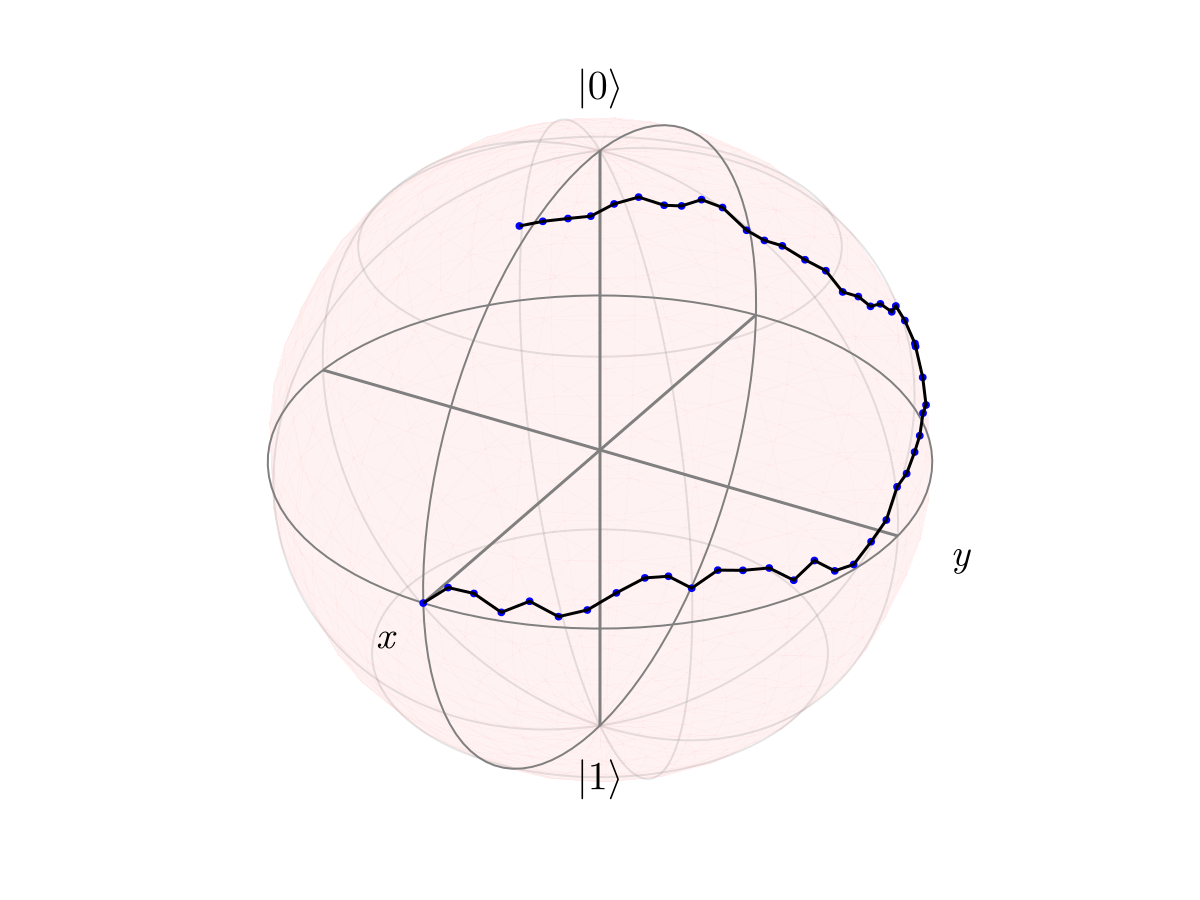

In [14]:
traj_ket = get_trajectory(qcp)
fig2 = plot_bloch(traj_ket)

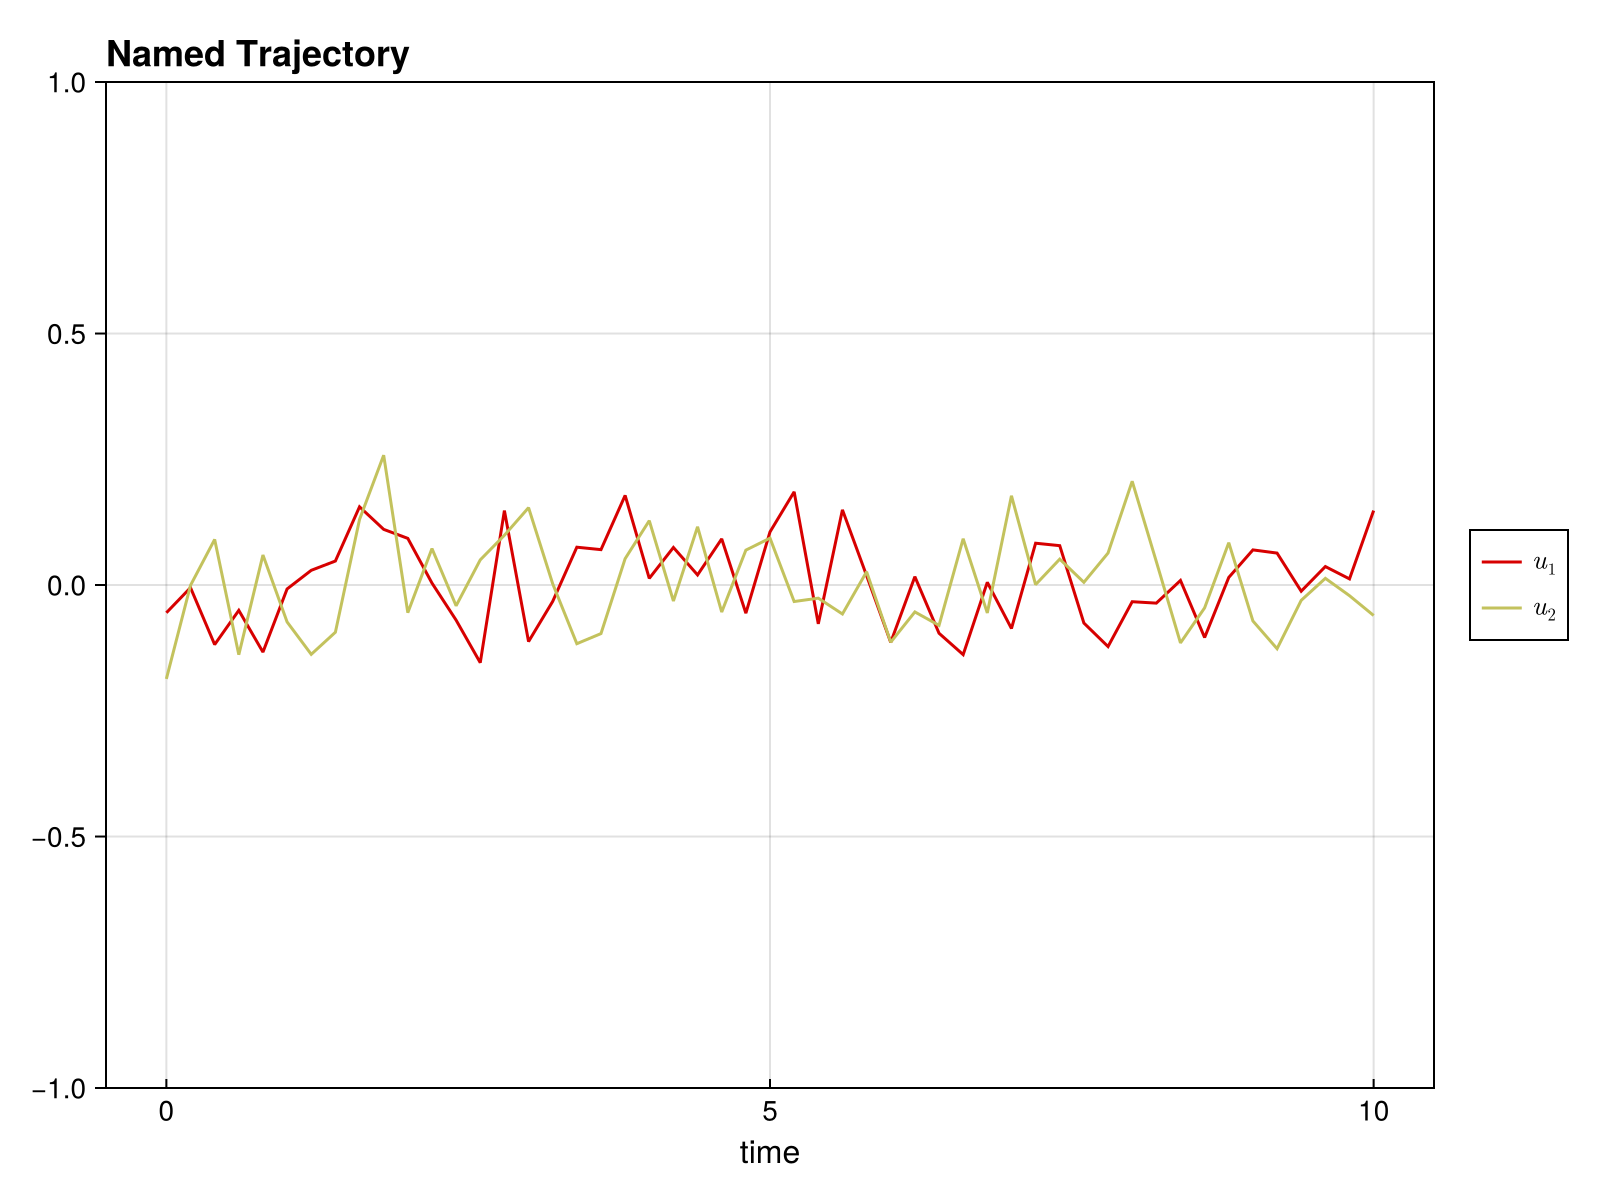

In [15]:
plot(traj_ket, :u)

In [16]:
solve!(qcp, max_iter=100, options=IpoptOptions(eval_hessian=true))

    initializing optimizer...
        applying constraint: timesteps all equal constraint
        applying constraint: initial value of ψ̃
        applying constraint: initial value of u
        applying constraint: final value of u
        applying constraint: bounds on ψ̃
        applying constraint: bounds on u
        applying constraint: bounds on du
        applying constraint: bounds on ddu
        applying constraint: bounds on Δt
        applying constraint: time consistency constraint (t_{k+1} = t_k + Δt_k)
        applying constraint: initial time t₁ = 0

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running wi

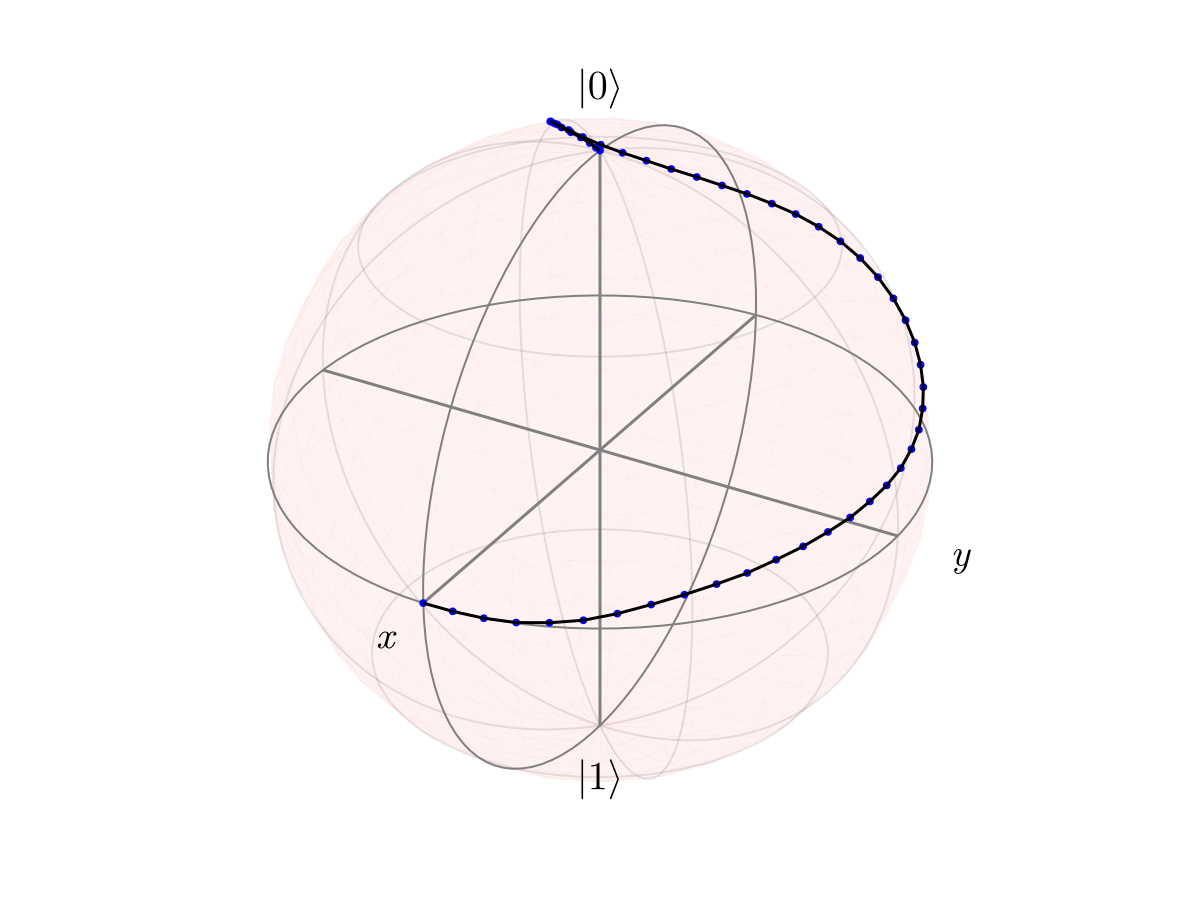

In [17]:
traj_ket_opt = get_trajectory(qcp)
using QuantumToolbox
fig3 = plot_bloch(traj_ket_opt)

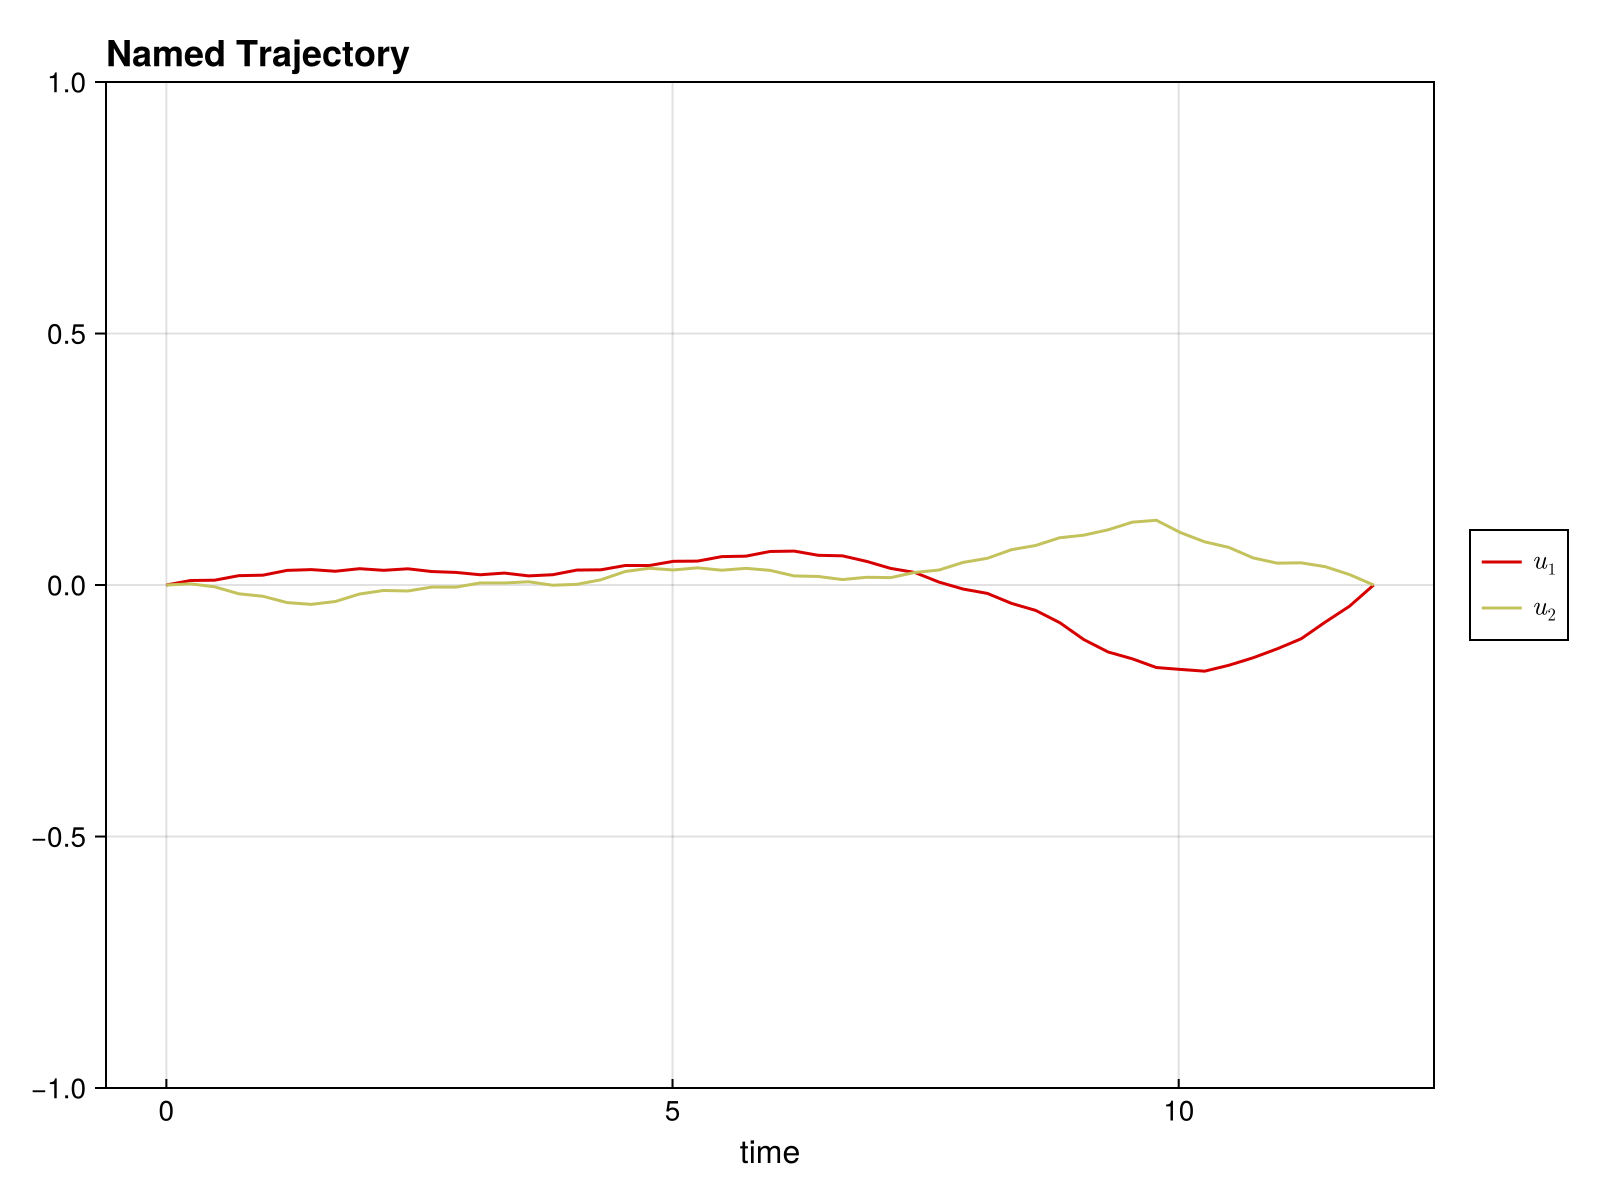

In [18]:
plot(traj_ket_opt, :u)

**CZ gate**

\begin{equation}
    H(t) = \sum_j \tfrac{\eta}{2} a_j^\dagger a_j^\dagger a_j a_j + \Delta(t) (a_1^\dagger a_1) + g(t) (a_1^\dagger a_2 + a_1 a_2^\dagger)
\end{equation} 

In [19]:
n_levels = 3
a = lift_operator(annihilate(n_levels), 1, 2)
b = lift_operator(annihilate(n_levels), 2, 2)
η = -0.3

H_drift = η/2 * (a'a'*a*a + b'b'*b*b)
H_drives = [a*a', (a'b + a*b')]
transmons = QuantumSystem(H_drift, H_drives, drive_bounds)

U_goal = EmbeddedOperator(
    GATES.CZ, 
    get_subspace_indices([1:2, 1:2], [n_levels, n_levels]), 
    [n_levels, n_levels]
)

EmbeddedOperator{ComplexF64}(ComplexF64[1.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 1.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; … ; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 + 0.0im], [1, 2, 4, 5], [3, 3])

In [20]:
commutator(A, B) = A * B - B * A

commutator (generic function with 1 method)

In [21]:
A = H_drives[1]
B = H_drives[2]
commutator(A, B) |> sparse

9×9 SparseMatrixCSC{ComplexF64, Int64} with 8 stored entries:
     ⋅          ⋅              ⋅      …          ⋅          ⋅          ⋅    
     ⋅          ⋅              ⋅                 ⋅          ⋅          ⋅    
     ⋅          ⋅              ⋅                 ⋅          ⋅          ⋅    
     ⋅      1.0+0.0im          ⋅                 ⋅          ⋅          ⋅    
     ⋅          ⋅      1.41421+0.0im     2.82843+0.0im      ⋅          ⋅    
     ⋅          ⋅              ⋅      …          ⋅      4.0+0.0im      ⋅    
     ⋅          ⋅              ⋅                 ⋅          ⋅          ⋅    
     ⋅          ⋅              ⋅                 ⋅          ⋅          ⋅    
     ⋅          ⋅              ⋅                 ⋅          ⋅          ⋅    

In [22]:
#  is_reachable(U_goal, transmons)

**Continous-variable quantum computing**

\begin{equation}
    H(t) = \Omega(t) a^\dagger + \Omega(t) a + \kappa(t) a^2 + \kappa^*(t) (a^\dagger)^2
\end{equation}

In [23]:
n_levels = 10

a = annihilate(n_levels)
X = a + a'
Y = -im * (a - a')
X2 = a^2 + (a')^2
Y2 = -im * (a^2 - (a')^2)

Ω = 1.0
κ = 0.1

sys = QuantumSystem([X, Y, X2, Y2], [1.0, 1.0, 0.5, 0.5])

# Displacement and squeezing operators
function displacement(α)
    return exp(α * a' - conj(α) * a)
end

function squeezing(r)
    return exp((r / 2) * (a^2 - (a')^2))
end

# Initial states
ψ0 = I(n_levels)[:, 1] .+ 0.0im
ψα = displacement(im * 1.5) * ψ0;
ψs = squeezing(0.5) * displacement(0.5 + 0.5im) * ψ0;

## Coherent state

In [24]:
N = 51
Δt = 0.4
T = Δt * (N - 1)
pulse = ZeroOrderPulse(0.1 * randn(4, N), collect(range(0, T, length = N)))
qtraj = KetTrajectory(sys, pulse, ψ0, ψα)
qcp = SmoothPulseProblem(qtraj, N)
solve!(qcp, max_iter=75, options=IpoptOptions(eval_hessian=true))

    constructing SmoothPulseProblem for KetTrajectory...
	applying timesteps_all_equal constraint: Δt
    initializing optimizer...
        applying constraint: timesteps all equal constraint
        applying constraint: initial value of ψ̃
        applying constraint: initial value of u
        applying constraint: final value of u
        applying constraint: bounds on ψ̃
        applying constraint: bounds on u
        applying constraint: bounds on du
        applying constraint: bounds on ddu
        applying constraint: bounds on Δt
        applying constraint: time consistency constraint (t_{k+1} = t_k + Δt_k)
        applying constraint: initial time t₁ = 0
This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:    94637
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:    86479

Total number of variables............................:     17

In [25]:
Piccolo.Quantum.Rollouts.fidelity(qcp)

0.9999647756428046

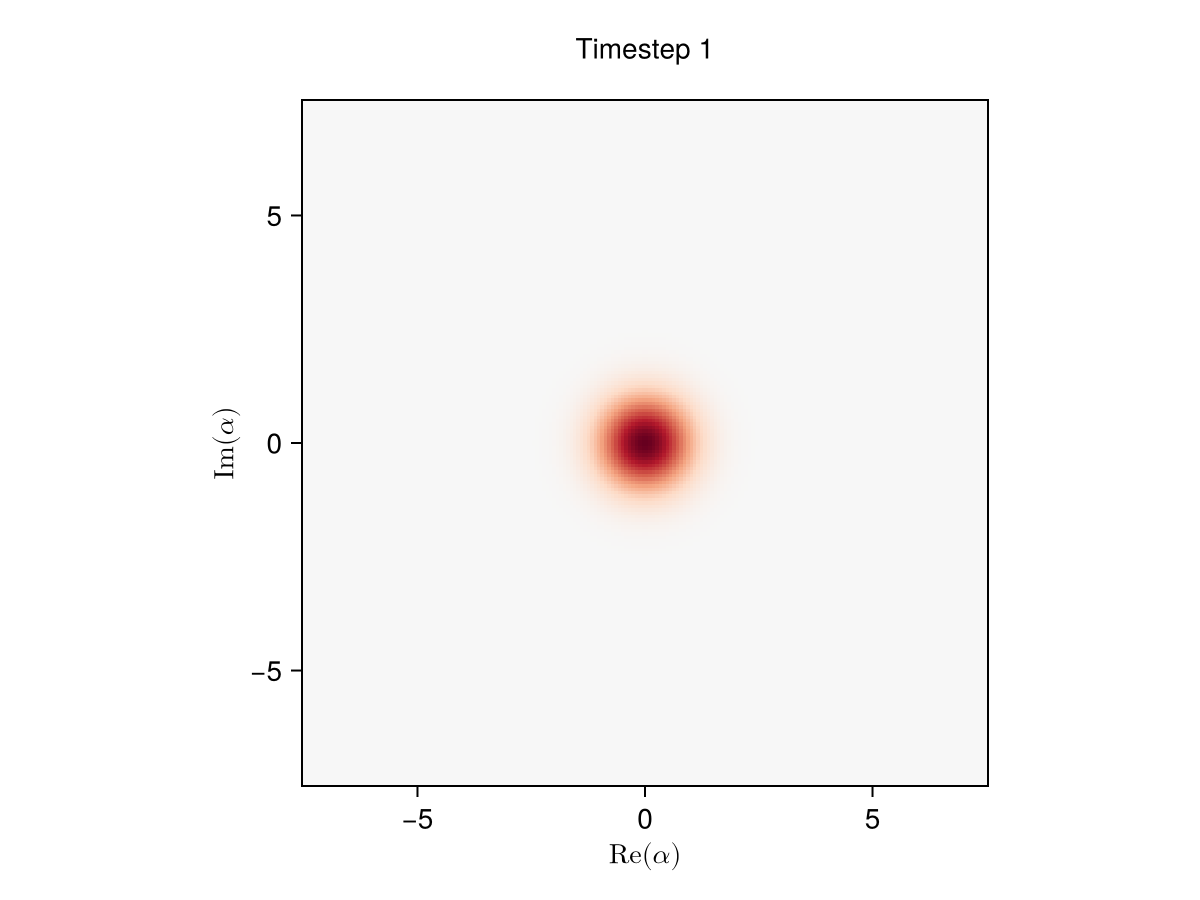

In [26]:
traj_ket_opt = get_trajectory(qcp)
fig = plot_wigner(traj_ket_opt, 1)
fig

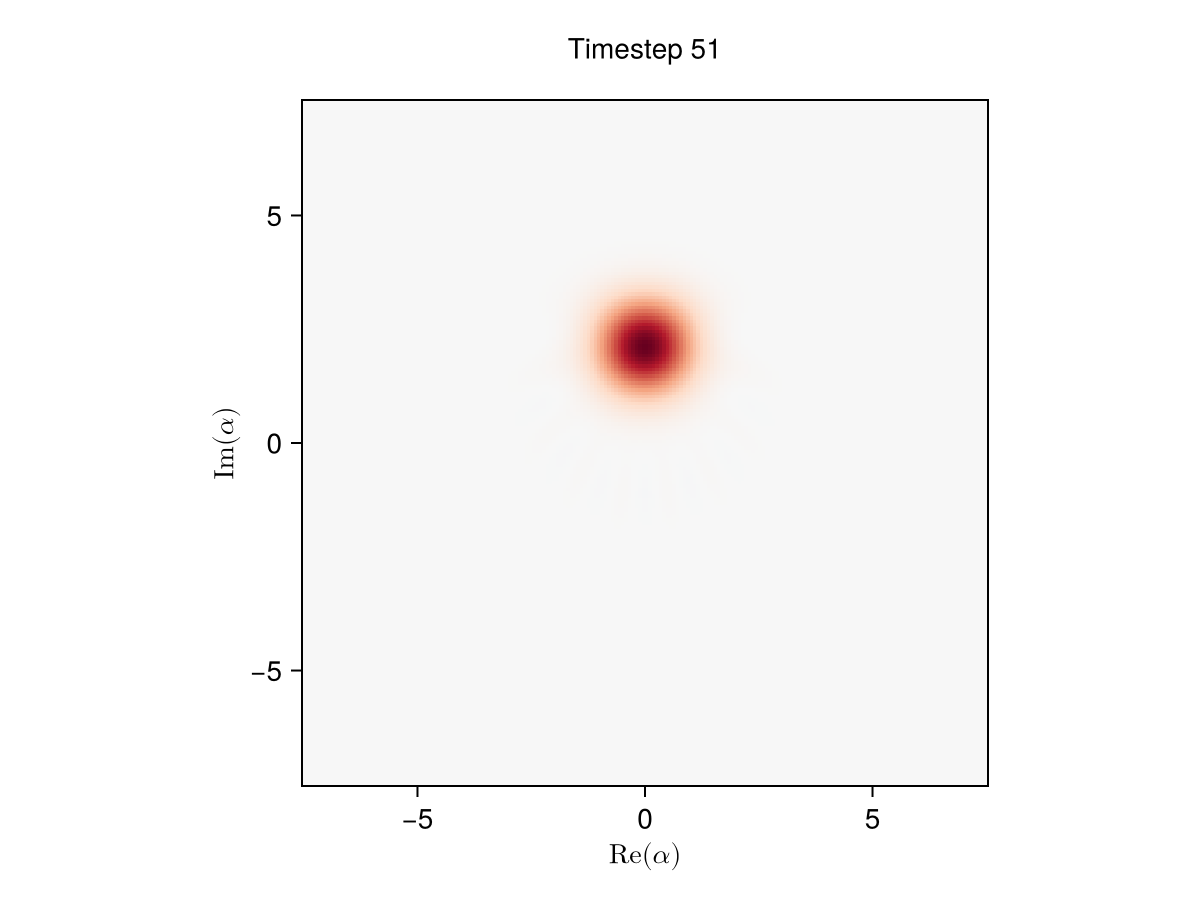

In [27]:
fig = plot_wigner(traj_ket_opt, N)
fig

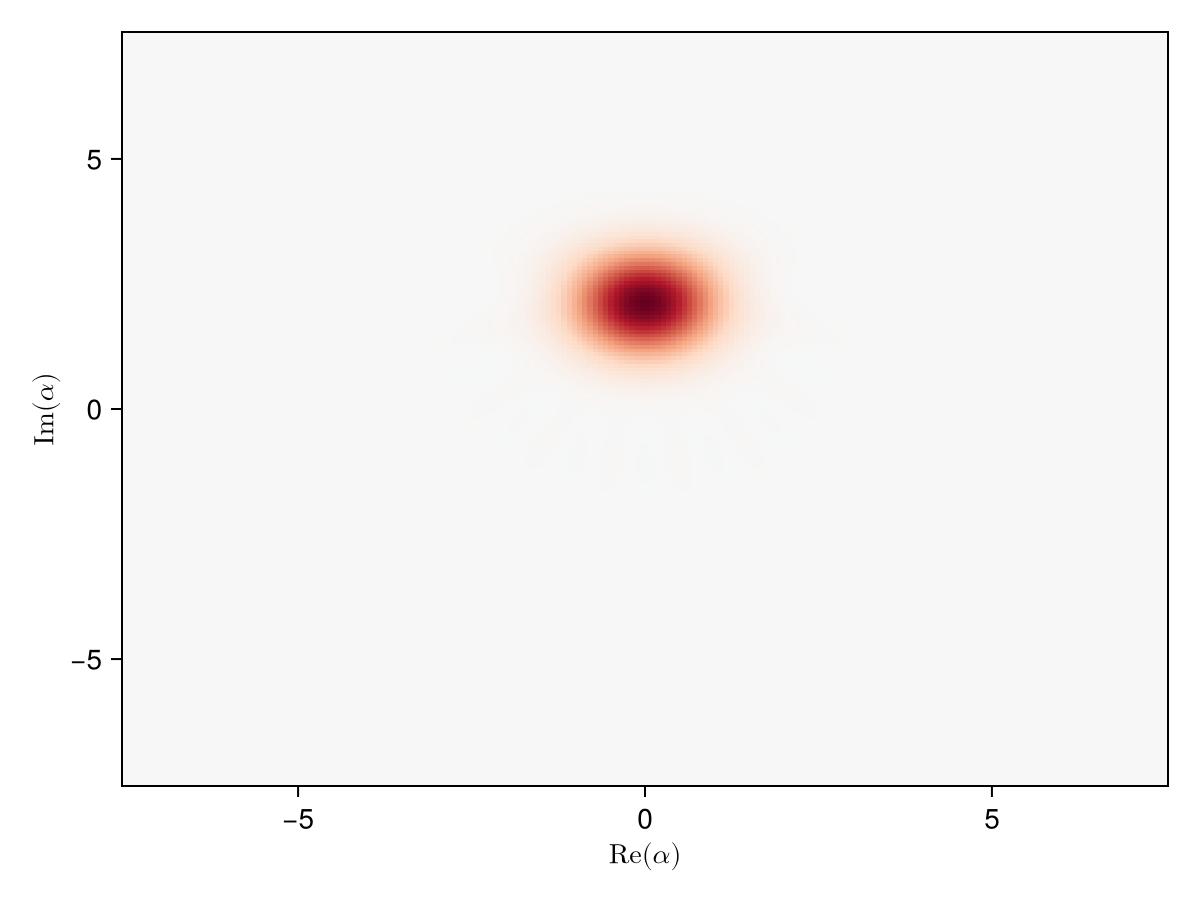

In [28]:
fig = plot_wigner(QuantumObject(ψα))
fig[1]

In [ ]:
plot(
    traj_ket_opt, [:u],
    transformations = [:ψ̃ => ψ̃ -> abs2.(iso_to_ket(ψ̃)),],
    use_autolimits=true,
    transformation_titles = ["Population"],
)

### Minimum Time

In [ ]:
min_prob = MinimumTimeProblem(qcp, final_fidelity=0.99)

In [ ]:
solve!(min_prob, max_iter=100)

In [ ]:
traj_ket_min = get_trajectory(min_prob)
fig = plot_wigner(traj_ket_min, N)
fig

In [ ]:
plot(
    traj_ket_min, [:u],
    transformations = [:ψ̃ => ψ̃ -> abs2.(iso_to_ket(ψ̃)),],
    use_autolimits=true,
    transformation_titles = ["Population"],
)

## Squeezed states

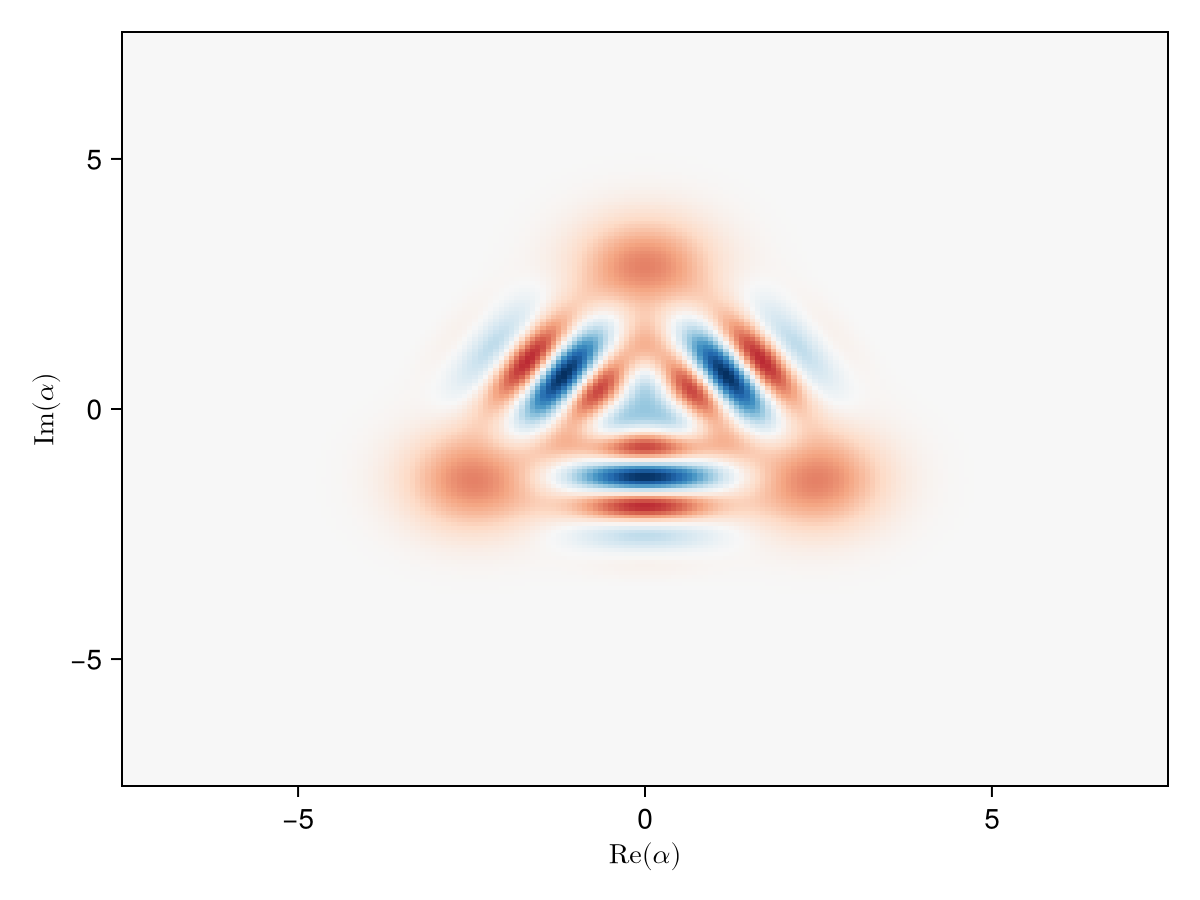

In [29]:
# Three-legged cat state — pure QuantumToolbox visualization
N_qt = 30  # ground truth reference (independent of n_levels)
ρ_cat = 2.0  # |α|² = 4, ~99% captured in 10 Fock levels
α1 = ρ_cat * exp(im * π/2)
α2 = ρ_cat * exp(im * (π/2 + 2π/3))
α3 = ρ_cat * exp(im * (π/2 + 4π/3))

ψ_cat3_qt = normalize(coherent(N_qt, α1) + coherent(N_qt, α2) + coherent(N_qt, α3))
fig_cat3_qt = plot_wigner(ψ_cat3_qt)
fig_cat3_qt[1]

In [ ]:
# Diagnose: how well does displacement(α)*ψ0 in n_levels=5 match the true coherent state?
ψ_cat3_piccolo = normalize(
    displacement(α1) * ψ0 +
    displacement(α2) * ψ0 +
    displacement(α3) * ψ0
)

# Truncate ψ_cat3_qt to n_levels and compare
qt_trunc = normalize(ψ_cat3_qt.data[1:n_levels])
fid = abs2(dot(ψ_cat3_piccolo, qt_trunc))
println("Fidelity vs ground truth (truncated to n_levels=$n_levels): $(round(fid, digits=4))")

# Show what the Piccolo target actually looks like in phase space
plot_wigner(QuantumObject(ψ_cat3_piccolo))[1]

In [30]:
# Three-legged cat state optimization (ρ_cat and α1/α2/α3 defined in cell above)
ψ_cat3 = normalize(
    displacement(α1) * ψ0 +
    displacement(α2) * ψ0 +
    displacement(α3) * ψ0
)

N_cat = 101
Δt_cat = 0.4
T_cat = Δt_cat * (N_cat - 1)
pulse_cat = ZeroOrderPulse(0.1 * randn(4, N_cat), collect(range(0, T_cat, length = N_cat)))
qtraj_cat = KetTrajectory(sys, pulse_cat, ψ0, ψ_cat3)
qcp_cat = SmoothPulseProblem(qtraj_cat, N_cat)
solve!(qcp_cat, max_iter=200, options=IpoptOptions(eval_hessian=true))

    constructing SmoothPulseProblem for KetTrajectory...
	applying timesteps_all_equal constraint: Δt
    initializing optimizer...
        applying constraint: timesteps all equal constraint
        applying constraint: initial value of ψ̃
        applying constraint: initial value of u
        applying constraint: final value of u
        applying constraint: bounds on ψ̃
        applying constraint: bounds on u
        applying constraint: bounds on du
        applying constraint: bounds on ddu
        applying constraint: bounds on Δt
        applying constraint: time consistency constraint (t_{k+1} = t_k + Δt_k)
        applying constraint: initial time t₁ = 0
This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:   190087
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:   174029

Total number of variables............................:     34

In [ ]:
traj_ket_cat = get_trajectory(qcp_cat)
fig_cat = plot_wigner(traj_ket_cat, N_cat)

In [ ]:
plt_cat = ψ_cat3 |> QuantumObject |> plot_wigner
plt_cat[1]